# Fixture-level ensemble model

Combine pre-season and in-season predictions with fixture context to
predict fixture-level FPL points.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

from prediction.artifacts.io import ENSEMBLE_ARTIFACT_PATH, save_trained_catboost_model
from training.config import RANDOM_STATE, TARGET_COLUMN
from training.transformations import create_ensemble_training_df

TRAINING_SEASON = "2024-25"
VALIDATION_SEASON = "2025-26"
CATEGORICAL_COLUMNS = ["team", "position", "target_gw", "was_home"]
MODEL_FEATURES = CATEGORICAL_COLUMNS + [
    "pre_season_model_score",
    "in_season_model_score",
    "player_game_difficulty",
    "opponent_game_difficulty",
]
CATBOOST_PARAMS = {
    "iterations": 163,
    "learning_rate": 0.03,
    "depth": 6,
    "loss_function": "RMSE",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
}

## Load data

In [2]:
training_df = create_ensemble_training_df(
    season=TRAINING_SEASON, pre_season="2023-24"
)
validation_df = create_ensemble_training_df(
    season=VALIDATION_SEASON, pre_season=TRAINING_SEASON
)
print(f"Training rows: {len(training_df):,}; validation rows: {len(validation_df):,}")

Training rows: 27,605; validation rows: 29,747


## Prepare training and validation data

In [3]:
X_train = training_df[MODEL_FEATURES].copy()
X_valid = validation_df[MODEL_FEATURES].copy()
y_train = training_df[TARGET_COLUMN].copy()
y_valid = validation_df[TARGET_COLUMN].copy()

for frame in (X_train, X_valid):
    frame[CATEGORICAL_COLUMNS] = (
        frame[CATEGORICAL_COLUMNS].fillna("__MISSING__").astype(str)
    )

## Train candidate models

In [4]:
def fit_catboost(sample_weight=None):
    return CatBoostRegressor(**CATBOOST_PARAMS).fit(
        X_train,
        y_train,
        cat_features=CATEGORICAL_COLUMNS,
        sample_weight=sample_weight,
    )

validation_predictions = {}
unweighted_model = fit_catboost()
validation_predictions["Unweighted"] = unweighted_model.predict(X_valid)

basic_weights = pd.Series(1.0, index=y_train.index)
basic_weights.loc[y_train > 6] = 4.0
basic_weighting_model = fit_catboost(sample_weight=basic_weights)
validation_predictions["Basic weighting"] = basic_weighting_model.predict(X_valid)

score_percentiles = training_df.groupby(["season", "target_gw"])[TARGET_COLUMN].rank(
    pct=True, method="average"
)
percentile_weights = pd.cut(
    score_percentiles,
    bins=[0, 0.25, 0.50, 0.75, 0.90, 1.0],
    labels=[1.0, 1.5, 2.0, 3.0, 4.0],
    include_lowest=True,
).astype(float)
percentile_weighting_model = fit_catboost(sample_weight=percentile_weights)
validation_predictions["Percentile weighting"] = percentile_weighting_model.predict(
    X_valid
)

## Evaluate models

In [5]:
pre_season_player_scores = training_df[
    ["season", "player_id", "position", "pre_season_model_score"]
].drop_duplicates(["season", "player_id"])
pre_season_score_by_position = pre_season_player_scores.groupby("position")[
    "pre_season_model_score"
].median()
pre_season_score_fallback = pre_season_player_scores[
    "pre_season_model_score"
].median()
validation_df["pre_season_score_with_fallback"] = (
    validation_df["pre_season_model_score"]
    .fillna(validation_df["position"].map(pre_season_score_by_position))
    .fillna(pre_season_score_fallback)
)
validation_predictions = {
    "Pre-season only": validation_df["pre_season_score_with_fallback"],
    "In-season only": validation_df["in_season_model_score"],
    **validation_predictions,
}

def evaluate_predictions(predictions, top_fraction=0.10):
    evaluation = validation_df[["season", "target_gw", TARGET_COLUMN]].rename(
        columns={TARGET_COLUMN: "actual"}
    ).assign(predicted=np.asarray(predictions))
    top_decile_results = []
    for _, gameweek in evaluation.groupby(["season", "target_gw"]):
        count = max(1, int(np.ceil(len(gameweek) * top_fraction)))
        predicted_top = gameweek.nlargest(count, "predicted")
        actual_top_indices = set(gameweek.nlargest(count, "actual").index)
        top_decile_results.append({
            "top_decile_avg_actual_points": predicted_top["actual"].mean(),
            "top_decile_hit_rate": predicted_top.index.isin(actual_top_indices).mean(),
            "top_decile_oracle_regret": (
                gameweek.nlargest(count, "actual")["actual"].mean()
                - predicted_top["actual"].mean()
            ),
        })
    return {
        "MAE": mean_absolute_error(evaluation["actual"], evaluation["predicted"]),
        "RMSE": root_mean_squared_error(evaluation["actual"], evaluation["predicted"]),
        "R2": r2_score(evaluation["actual"], evaluation["predicted"]),
        **pd.DataFrame(top_decile_results).mean().to_dict(),
    }

comparison_table = (
    pd.DataFrame.from_dict(
        {
            name: evaluate_predictions(predictions)
            for name, predictions in validation_predictions.items()
        },
        orient="index",
    )
    .rename_axis("model")
    .reset_index()
    .sort_values("top_decile_avg_actual_points", ascending=False)
    .reset_index(drop=True)
)
comparison_table.round(3)

,model,MAE,RMSE,R2,top_decile_avg_actual_points,top_decile_hit_rate,top_decile_oracle_regret
0,Percentile weighting,1.154,1.971,0.297,3.876,0.371,3.267
1,Unweighted,0.990,1.945,0.316,3.870,0.369,3.273
2,Basic weighting,1.258,2.100,0.203,3.864,0.366,3.279
3,In-season only,1.033,1.976,0.294,3.702,0.347,3.441
4,Pre-season only,1.452,2.257,0.079,2.783,0.247,4.360


## Explain selected model

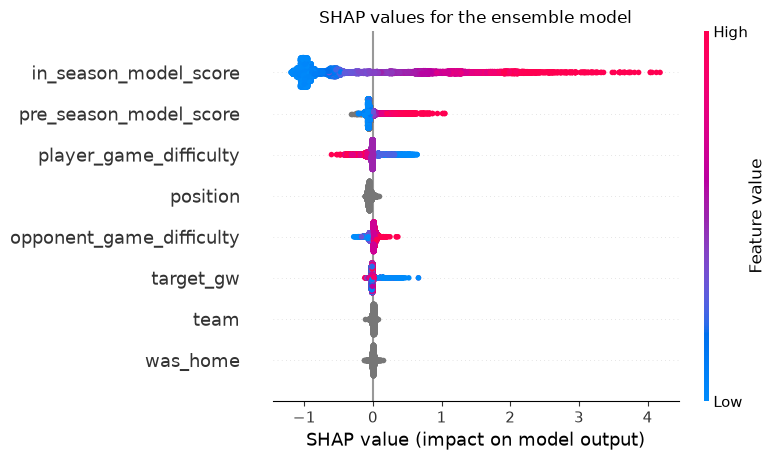

In [6]:
shap_sample_df = X_valid.sample(
    n=min(10_000, len(X_valid)), random_state=RANDOM_STATE
)
shap_values = shap.TreeExplainer(unweighted_model)(shap_sample_df)
shap.plots.beeswarm(shap_values, max_display=len(MODEL_FEATURES), show=False)
plt.title("SHAP values for the ensemble model")
plt.tight_layout()
plt.show()

## Export selected model

In [7]:
save_trained_catboost_model(
    model=unweighted_model,
    feature_columns=MODEL_FEATURES,
    categorical_columns=CATEGORICAL_COLUMNS,
    model_name="ensemble_unweighted",
    model_version="0.2.0",
    save_path=ENSEMBLE_ARTIFACT_PATH,
)
print(f"Saved ensemble model to {ENSEMBLE_ARTIFACT_PATH}")

Saved ensemble model to /Users/calumthompson/Documents/fantasy_football_v2/src/prediction/artifacts/trained_models/ensemble_model.joblib
